In [1]:
# ==============================================================
import numpy as np
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.feature import ShapelyFeature
import cartopy.io.shapereader as shpreader


import sys
sys.path.append("/home/nchoi21/utils/python/nbchoi")
import f_nchoi as nb

import colormaps as cmaps
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy import signal

import os 
import glob
import subprocess
import regionmask

import pandas as pd
import xarray as xr
warnings.filterwarnings("ignore", category=UserWarning)
# ==============================================================

In [2]:
## OPEN UFS FILES 
mod = xr.open_dataset('/scratch/nchoi21/CMIP/HighResMIP/climate/Regrid_25yrs_ann_clim_pr.nc').pr[:,0:5,:,:].mean('time')
print(mod)

lsm = regionmask.defined_regions.natural_earth_v5_0_0.land_110  # 110m resolution
mask = lsm.mask(mod.coords['longitude'], mod.coords['latitude'])
ocean_mask = xr.where(mask.isnull(), 1, 0)
#mod = mod.where(ocean_mask == 1)

## GPCP
mod[0,:,:] = xr.open_dataset('/scratch/nchoi21/GPCP/GPCP3.3/regrid/GPCP3.3_25yrs_ann_clim_pr.nc').pr[0:5,:,:].mean('month')

<xarray.DataArray 'pr' (model: 10, latitude: 181, longitude: 360)> Size: 5MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.13868313, 0.13797193, 0.13587902, ..., 0.13803468,
         0.13822785, 0.13935012],
        [0.11616853, 0.11396358, 0.11134087, ..., 0.1166716 ,
         0.11762014, 0.11680325],
        ...,
        [0.45580311, 0.45480093, 0.45468398, ..., 0.45450131,
         0.45408626, 0.45455473],
        [0.43574939, 0.436283  , 0.43664659, ..., 0.43477978,
         0.43514469, 0.43526833],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [0.27213289, 0.27202471, 0.27197028, ..., 0.27262641,
         0.27240463, 0.27225305],
        [0.23582731, 0.23553292, 0.23449599, ..., 0.23656025,
         0.23632176, 0.2360424 ],
...
        [       nan, 0.39990499, 0.39990

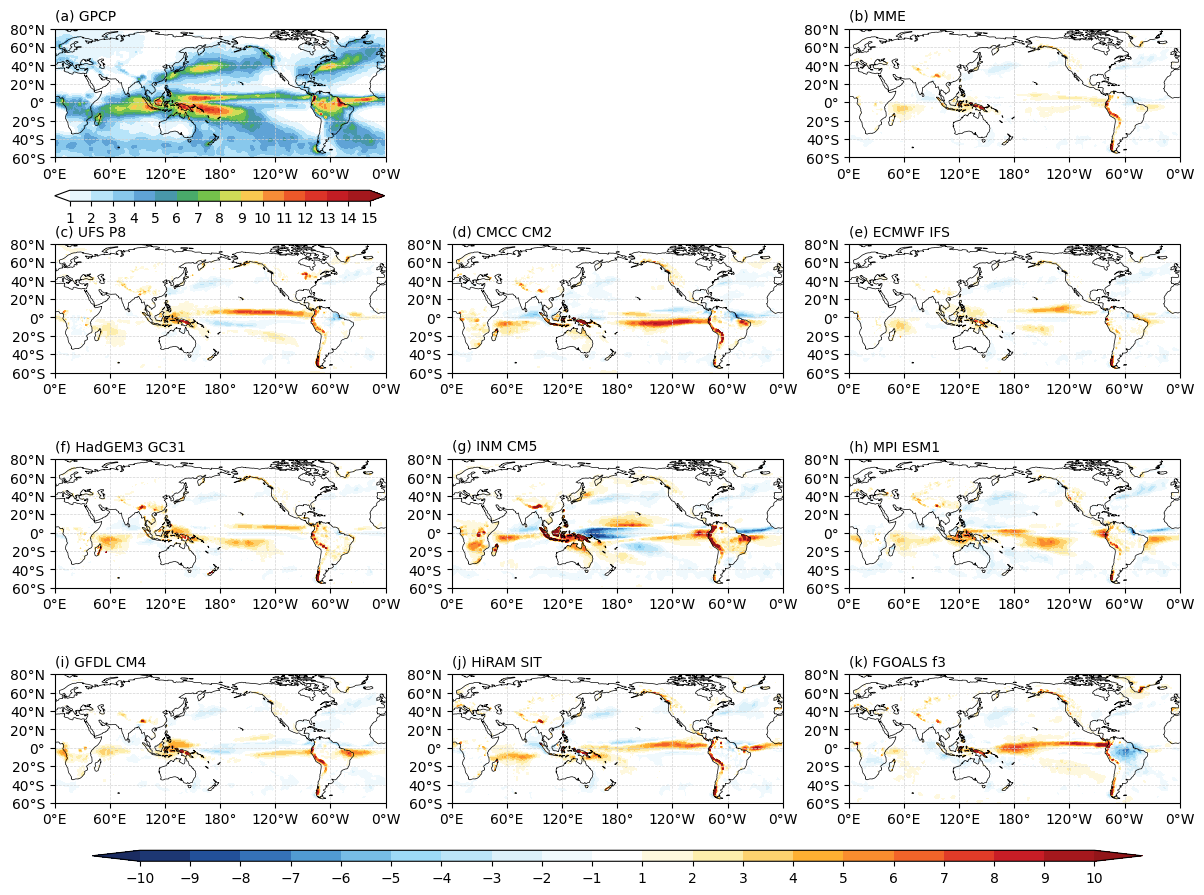

In [3]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(15,11))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(1,16,1)
plt.subplot(431,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('(a) GPCP',loc='left',fontsize=10)
cax = plt.axes([0.05,0.77,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-10,11,1)
clevs = clevs[clevs!=0]

plt.subplot(4,3,3,projection=projection)
a=plt.contourf(longitude,latitude,mod[1:,:,:].mean('model') - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(b) MME',loc='left',fontsize=10)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n,projection=projection)
    a=plt.contourf(longitude,latitude,mod[n+1,:,:] - mod[0,:,:],levels=clevs,extend='both')
    plt.gca().set_yticks(lat_tick,crs=projection)
    plt.gca().set_xticks(lon_tick,crs=projection)
    plt.gca().xaxis.set_major_formatter(lon_formatter)
    plt.gca().yaxis.set_major_formatter(lat_formatter)
    plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
    plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
    plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
    label = f"({chr(99+n)}) {model[n+1]}"   # 99= 'c'부터 시작
    plt.gca().set_title(label, loc='left', fontsize=10)
    #plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.17,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

In [4]:
ufs = (mod[1]-mod[0]).sel(latitude=slice(-15,-5),longitude=slice(240,275))
print(ufs.mean(('latitude','longitude')))

ufs = (mod[1]).sel(latitude=slice(-15,-5),longitude=slice(240,275))
print(ufs.mean(('latitude','longitude')))

<xarray.DataArray 'pr' ()> Size: 8B
array(-0.45522067)
<xarray.DataArray 'pr' ()> Size: 8B
array(0.70674038)
Coordinates:
    model    <U15 60B 'UFS-P8-V16'


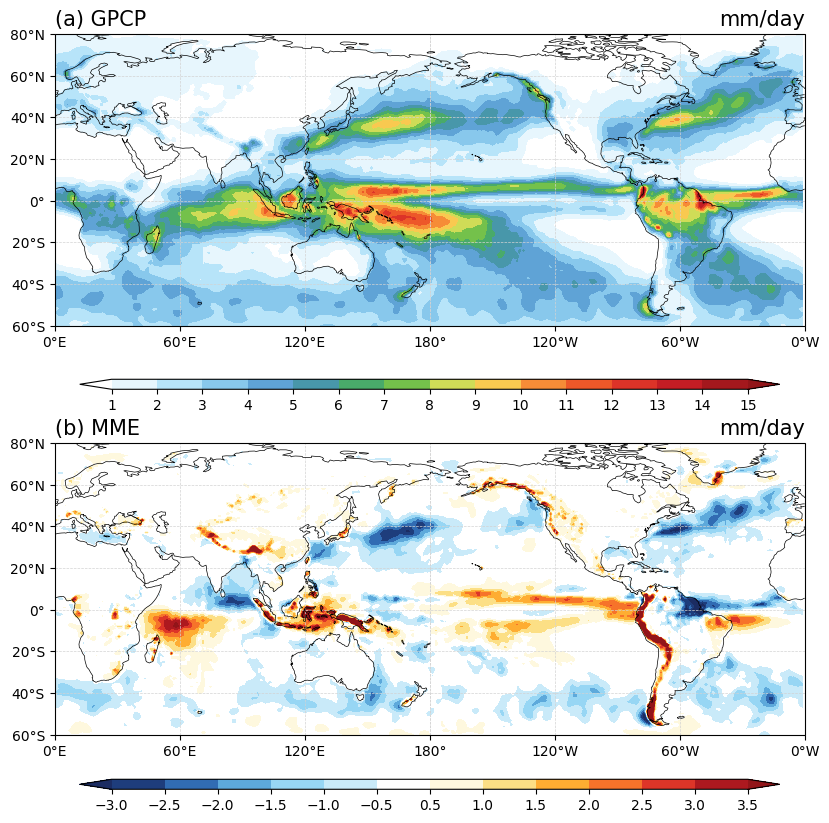

In [5]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(10,10))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['GPCP','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(1,16,1)
plt.subplot(211,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('(a) GPCP',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
cax = plt.axes([0.075,0.57,0.7,0.01])
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-3,4,0.5)
clevs = clevs[clevs!=0]

plt.subplot(2,1,2,projection=projection)
a=plt.contourf(longitude,latitude,mod[1:,:,:].mean('model') - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(b) MME',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)
    
cax = plt.axes([0.075,0.17,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.savefig('fig1ab.png', dpi=1000)

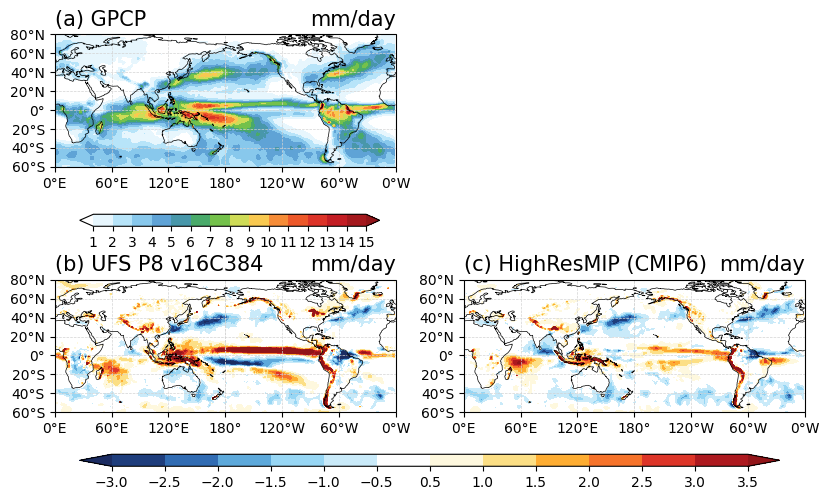

In [6]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(10,6))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['GPCP','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(1,16,1)
plt.subplot(221,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('(a) GPCP',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
cax = plt.axes([0.075,0.57,0.3,0.02])
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-3,4,0.5)
clevs = clevs[clevs!=0]

plt.subplot(2,2,4,projection=projection)
a=plt.contourf(longitude,latitude,mod[1:,:,:].mean('model') - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(c) HighResMIP (CMIP6)',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

plt.subplot(2,2,3,projection=projection)
a=plt.contourf(longitude,latitude,mod[1,:,:] - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(b) UFS P8 v16C384',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)
    
cax = plt.axes([0.075,0.17,0.7,0.02]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

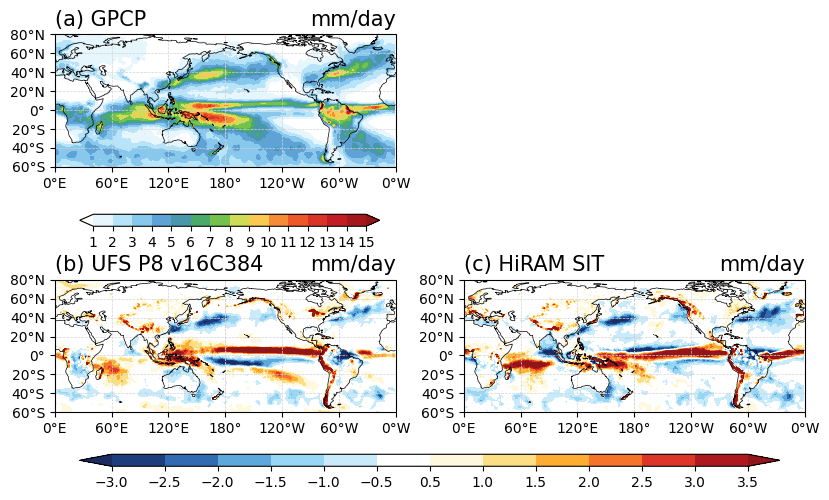

In [7]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(10,6))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['GPCP','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(1,16,1)
plt.subplot(221,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('(a) GPCP',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
cax = plt.axes([0.075,0.57,0.3,0.02])
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-3,4,0.5)
clevs = clevs[clevs!=0]

plt.subplot(2,2,4,projection=projection)
a=plt.contourf(longitude,latitude,mod[8,:,:] - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(c) HiRAM SIT',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

plt.subplot(2,2,3,projection=projection)
a=plt.contourf(longitude,latitude,mod[1,:,:] - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('(b) UFS P8 v16C384',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)
    
cax = plt.axes([0.075,0.17,0.7,0.02]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

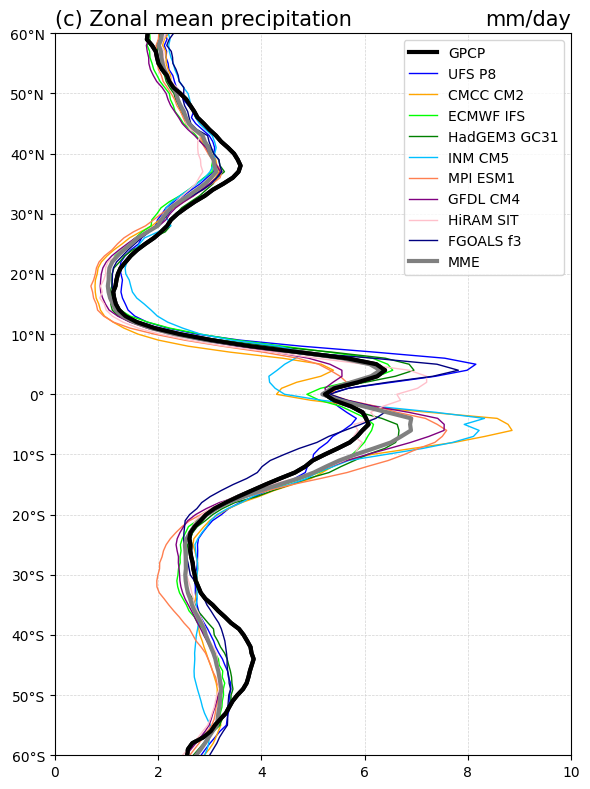

In [8]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
cc=plt.plot(mod[0].mean('longitude'), mod.coords['latitude'], color=color[0],linewidth=3,label=model[0])
for m in range(1,10):
    cc=plt.plot(mod[m].mean('longitude'), mod.coords['latitude'], color=color[m],linewidth=1,label=model[m])

c=plt.plot(mod[1:].mean(('model','longitude')), mod.coords['latitude'], color="gray",linewidth=3, label='MME')
c=plt.plot(mod[0].mean('longitude'), mod.coords['latitude'], color="black",linewidth=3)
#c=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color="blue",linewidth=3)
#c=plt.plot(gpcp.mean('longitude'), mod.coords['latitude'], color="gray",linewidth=3, label ='GPCP')
#c=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color="blue",linewidth=3)
#c=plt.plot(ufs_mean.mean('longitude'), ufs_mean.coords['latitude'], color="blue",linewidth=3,label='UFS P8')
#c1=plt.plot(gpm.data, gpm.coords('latitude')[0].points, color="black",linewidth=2,label='GPCP')

plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-60,60)
plt.gca().set_xlim(0,10)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().legend()
plt.gca().set_title('(c) Zonal mean precipitation',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()

plt.savefig('fig1c.png', dpi=1000)

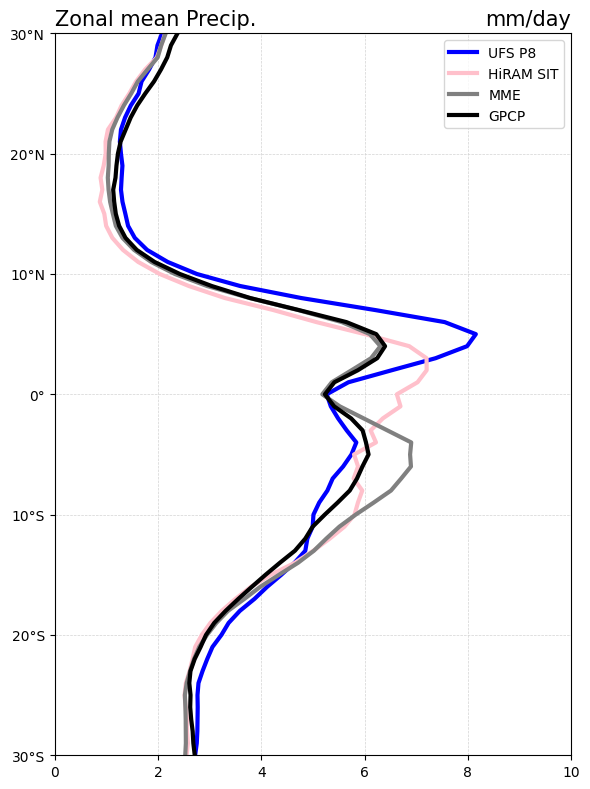

In [9]:
## PLOT Weekly Bias

#mod = mod.sel(longitude=slice(210,270))

fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
#for m in range(0,10):
#    cc=plt.plot(mod[m].mean('longitude'), mod.coords['latitude'], color=color[m],linewidth=1,label=model[m])
#cc=plt.plot(mod[3].mean('longitude'), mod.coords['latitude'], color=color[3],linewidth=3,label=model[3])
cc=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color=color[1],linewidth=3,label=model[1])
cc=plt.plot(mod[8].mean('longitude'), mod.coords['latitude'], color=color[8],linewidth=3,label=model[8])

#cc=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color=color[1],linewidth=3,label=model[1])
#cc=plt.plot(mod[9].mean('longitude'), mod.coords['latitude'], color=color[9],linewidth=3,label=model[9])

#cc=plt.plot(mod[2].mean('longitude'), mod.coords['latitude'], color=color[2],linewidth=3,label=model[2])
#cc=plt.plot(mod[5].mean('longitude'), mod.coords['latitude'], color=color[5],linewidth=3,label=model[5])
c=plt.plot(mod[1:].mean(('model','longitude')), mod.coords['latitude'], color="gray",linewidth=3, label='MME')
c=plt.plot(mod[0].mean('longitude'), mod.coords['latitude'], color="black",linewidth=3, label = 'GPCP')
#c=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color="blue",linewidth=3)

plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-30,30)
plt.gca().set_xlim(0,10)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().legend()
plt.gca().set_title('Zonal mean Precip.',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()

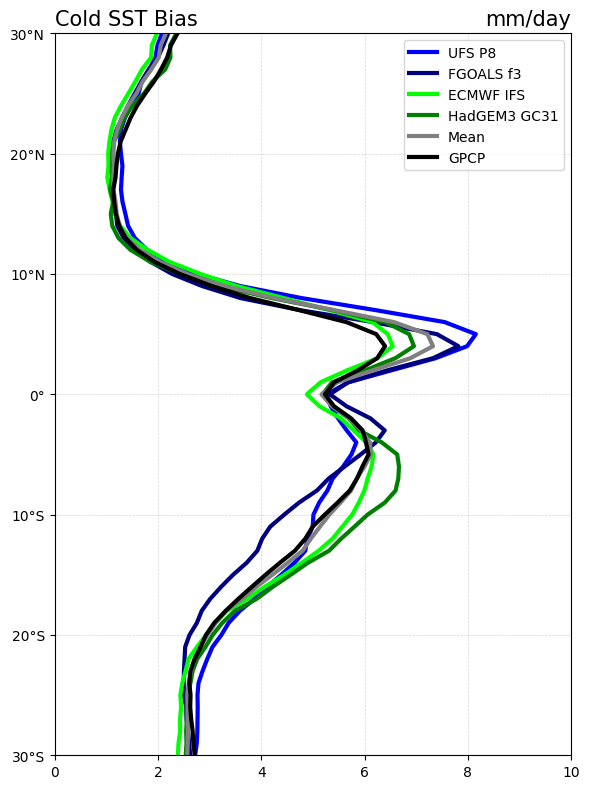

In [10]:
## PLOT Weekly Bias

#mod = mod.sel(longitude=slice(210,270))

fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
#for m in range(0,10):
#    cc=plt.plot(mod[m].mean('longitude'), mod.coords['latitude'], color=color[m],linewidth=1,label=model[m])
cc=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color=color[1],linewidth=3,label=model[1])
cc=plt.plot(mod[9].mean('longitude'), mod.coords['latitude'], color=color[9],linewidth=3,label=model[9])
cc=plt.plot(mod[3].mean('longitude'), mod.coords['latitude'], color=color[3],linewidth=3,label=model[3])
cc=plt.plot(mod[4].mean('longitude'), mod.coords['latitude'], color=color[4],linewidth=3,label=model[4])
c=plt.plot(mod[[1,3,4,9]].mean(('model','longitude')), mod.coords['latitude'], color="gray",linewidth=3, label='Mean')
c=plt.plot(mod[0].mean('longitude'), mod.coords['latitude'], color="black",linewidth=3, label = 'GPCP')
#c=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color="blue",linewidth=3)

plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-30,30)
plt.gca().set_xlim(0,10)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().legend()
plt.gca().set_title('Cold SST Bias',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()

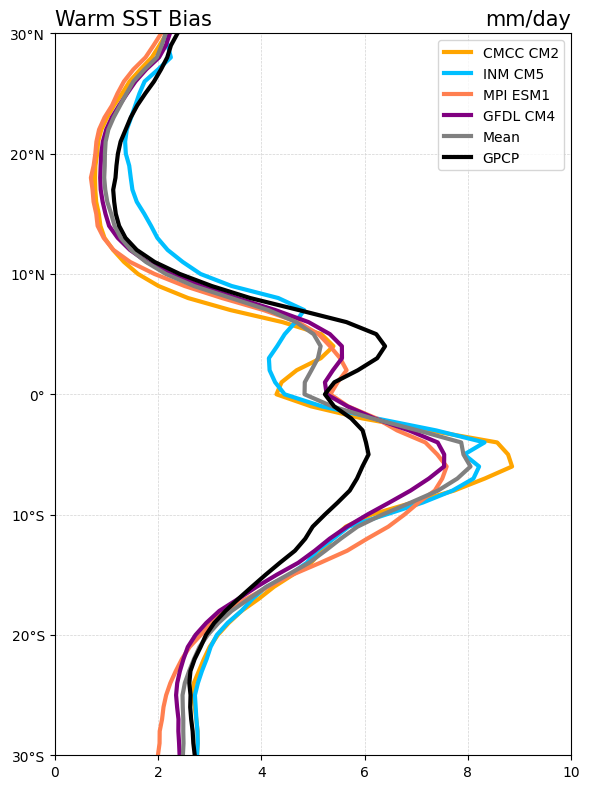

In [11]:
## PLOT Weekly Bias

#mod = mod.sel(longitude=slice(210,270))

fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
#for m in range(0,10):
#    cc=plt.plot(mod[m].mean('longitude'), mod.coords['latitude'], color=color[m],linewidth=1,label=model[m])
cc=plt.plot(mod[2].mean('longitude'), mod.coords['latitude'], color=color[2],linewidth=3,label=model[2])
cc=plt.plot(mod[5].mean('longitude'), mod.coords['latitude'], color=color[5],linewidth=3,label=model[5])
cc=plt.plot(mod[6].mean('longitude'), mod.coords['latitude'], color=color[6],linewidth=3,label=model[6])
cc=plt.plot(mod[7].mean('longitude'), mod.coords['latitude'], color=color[7],linewidth=3,label=model[7])
#cc=plt.plot(mod[9].mean('longitude'), mod.coords['latitude'], color=color[9],linewidth=3,label=model[9])

#cc=plt.plot(mod[2].mean('longitude'), mod.coords['latitude'], color=color[2],linewidth=3,label=model[2])
#cc=plt.plot(mod[5].mean('longitude'), mod.coords['latitude'], color=color[5],linewidth=3,label=model[5])
c=plt.plot(mod[[2,5,6,7]].mean(('model','longitude')), mod.coords['latitude'], color="gray",linewidth=3, label='Mean')
c=plt.plot(mod[0].mean('longitude'), mod.coords['latitude'], color="black",linewidth=3, label = 'GPCP')
#c=plt.plot(mod[1].mean('longitude'), mod.coords['latitude'], color="blue",linewidth=3)

plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-30,30)
plt.gca().set_xlim(0,10)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().legend()
plt.gca().set_title('Warm SST Bias',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()

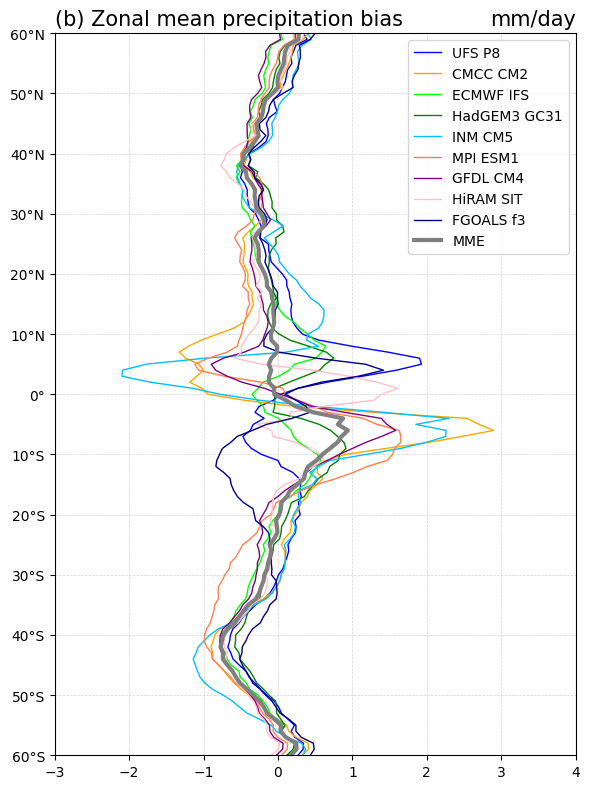

In [12]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
model = ['GPCP','UFS P8','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
for m in range(1,10):
    cc=plt.plot(mod[m].mean('longitude')-mod[0].mean('longitude'), mod.coords['latitude'], color=color[m],linewidth=1,label=model[m])

c=plt.plot(mod[1:].mean(('model','longitude'))-mod[0].mean('longitude'), mod.coords['latitude'], color="gray",linewidth=3, label='MME')
plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-60,60)
plt.gca().set_xlim(-3,4)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().legend()
plt.gca().set_title('(b) Zonal mean precipitation bias',loc='left',fontsize=15)
plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()

#plt.savefig('Fig_zonal_mean_annual_precip.png')

In [16]:
# Zonal mean
from eofs.xarray import Eof
mod_zm = mod[1:].mean('longitude')
obs_zm = mod[0].mean('longitude')
mod_zm = mod_zm - obs_zm
mod_zm = mod_zm - mod_zm.mean(dim='model')
#mod_zm = mod_zm.rename({'time':'init'})
mod_zm = mod_zm.rename({'model':'time'})
mod_zm = mod_zm.sel(latitude=slice(-30,30))
print(mod_zm)

solver = Eof(mod_zm)
eof = solver.eofs(neofs=3, eofscaling=2)  # Get the first 3 EOFs
pc = solver.pcs(npcs=3, pcscaling=1)  # Get the corresponding principal components
variance = solver.varianceFraction(neigs=3)*100

pc_std = pc.std(dim='time')  
eof = eof * pc_std *-1
pc = pc / pc_std * -1

pc.to_netcdf('DITCZ_index.nc')

<xarray.DataArray 'pr' (time: 9, latitude: 61)> Size: 4kB
array([[ 1.91345574e-01,  2.11219816e-01,  2.24783530e-01,
         2.29213438e-01,  2.38408366e-01,  2.44196179e-01,
         2.28622792e-01,  2.41424807e-01,  2.56218777e-01,
         2.56752918e-01,  2.79671598e-01,  2.37768904e-01,
         2.29025460e-01,  1.95580092e-01,  1.33829847e-01,
         4.44400996e-02, -6.82542894e-02, -1.66048170e-01,
        -3.64865388e-01, -5.16390446e-01, -8.17510634e-01,
        -1.05431829e+00, -1.23069695e+00, -1.32597958e+00,
        -1.31277293e+00, -1.13502649e+00, -1.06267422e+00,
        -7.86852774e-01, -4.88820141e-01, -1.73653168e-01,
         8.45128403e-02,  3.22110755e-01,  7.76751426e-01,
         1.24871487e+00,  1.67824859e+00,  2.05121659e+00,
         1.99188892e+00,  1.49348450e+00,  1.00039671e+00,
         6.39649438e-01,  4.25577278e-01,  3.19821136e-01,
         2.51492274e-01,  2.37816710e-01,  2.37198709e-01,
         2.41621896e-01,  2.39555929e-01,  2.40544453e-01

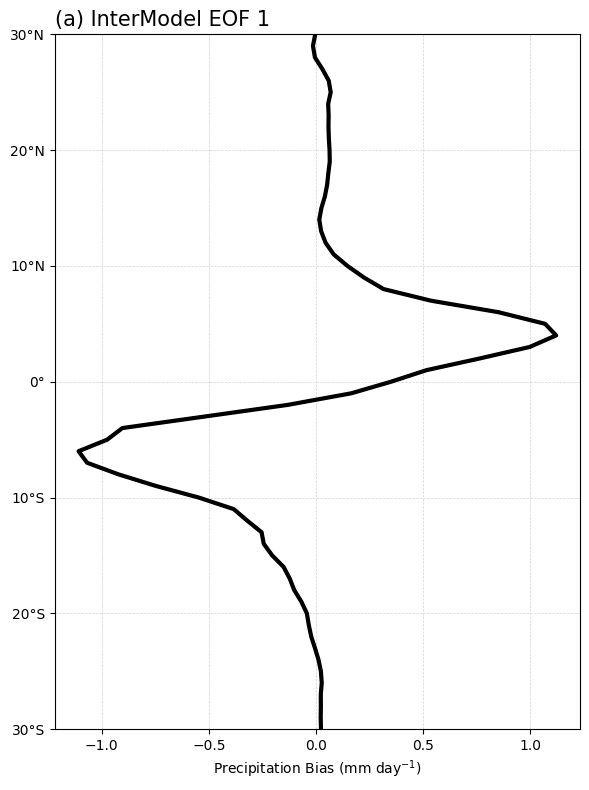

In [17]:
## PLOT Weekly Bias
fig = plt.figure(figsize=(6,8))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-90,91,10)
lat_formatter = LatitudeFormatter()

plt.subplot(1,1,1)
color = ["black","red","blue","green"]

for m in range(0,1):
    cc=plt.plot(eof[m,:], eof.coords['latitude'], color=color[m],linewidth=2, label='EOF '+str(m+1)+f" ({variance[m].values:.1f}%)")


cc=plt.plot(eof[0,:], eof.coords['latitude'], color=color[0],linewidth=3)

plt.gca().set_yticks(lat_tick)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_ylim(-30,30)
#plt.gca().set_xlim(0,10)
plt.gca().grid(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().legend()
plt.gca().set_xlabel(r'Precipitation Bias (mm day$^{-1}$)', fontsize=10)
plt.gca().set_title('(a) InterModel EOF 1',loc='left',fontsize=15)
#plt.gca().set_title('mm/day',loc='right',fontsize=15)
plt.tight_layout()
plt.tight_layout()
plt.savefig('fig2a.png', dpi=1000)

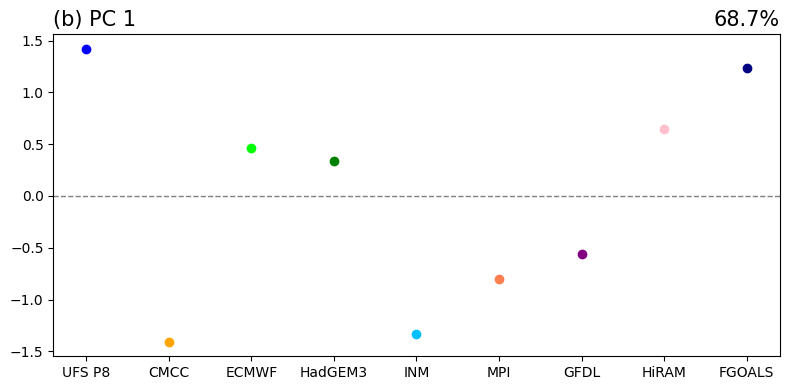

In [18]:
## PLOT 
fig = plt.figure(figsize=(8,4))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
color = ["blue","orange","lime","green","deepskyblue","coral","purple","pink","navy"]
plt.subplot(111)
for n in range(0,9):
    a=plt.plot(n+1,pc[n,0],color=color[n],marker='o', linestyle='None')
plt.gca().set_title('(b) PC 1',loc='left',fontsize=15)
plt.gca().set_title(f"{variance[0].values:.1f}%",loc='right',fontsize=15)
# Manually set x-axis labels
model = ['UFS P8','CMCC','ECMWF','HadGEM3','INM','MPI','GFDL','HiRAM','FGOALS']
plt.xticks(ticks=np.arange(1,10,1), labels=model)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

'''
plt.subplot(212)
for n in range(0,9):
    a=plt.plot(n+1,(pc[n,1]-pc[n,0])/np.sqrt(2),color=color[n],marker='o', linestyle='None')
plt.gca().set_title('PC 2',loc='left',fontsize=15)
plt.gca().set_title(f"{variance[1].values:.1f}%",loc='right',fontsize=15)
# Manually set x-axis labels
plt.xticks(ticks=np.arange(1,10,1), labels=model)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
'''
plt.tight_layout()
plt.savefig('fig2b.png',dpi=1000)